<a href="https://colab.research.google.com/github/vars1711/my_EV-ML_code/blob/main/ev_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import pandas
import pandas as pd

# Load the dataset
file_path = "/content/drive/MyDrive/Lithium-Ion Battery Cycle Life.csv"
df = pd.read_csv(file_path)

# Verify the dataset
print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: (114738, 13)
Columns: ['IR', 'QC', 'QD', 'Tavg', 'Tmin', 'Tmax', 'chargetime', 'cycle', 'battery_id', 'cycle_life', 'C1', 'Q1', 'C2']
         IR        QC        QD       Tavg       Tmin       Tmax  chargetime  \
0  0.000000  0.000000  0.000000   0.000000   0.000000   0.000000    0.000000   
1  0.016742  1.071042  1.070689  31.875011  29.566130  35.652016   13.341250   
2  0.016724  1.071674  1.071900  31.931490  29.604385  35.692978   13.425777   
3  0.016681  1.072304  1.072510  31.932603  29.744202  35.680588   13.425167   
4  0.016662  1.072970  1.073174  31.959322  29.644709  35.728691   13.341442   

   cycle battery_id  cycle_life   C1    Q1   C2  
0      1       b1c0      1190.0  3.6  80.0  3.6  
1      2       b1c0      1190.0  3.6  80.0  3.6  
2      3       b1c0      1190.0  3.6  80.0  3.6  
3      4       b1c0 

In [ ]:
df = df[df['cycle'] <= 100]
# Drop rows with missing target
df = df.dropna(subset=['cycle_life'])

# Fill missing feature values with median
feature_cols = ['IR', 'QC', 'QD', 'Tavg', 'Tmin', 'Tmax',
                'chargetime', 'cycle', 'C1', 'Q1', 'C2']

for col in feature_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Remove invalid sensor readings
df = df[(df['IR'] > 0) & (df['QC'] > 0) & (df['QD'] > 0)]

print(" Preprocessing complete. Final shape:", df.shape)

 Preprocessing complete. Final shape: (13743, 13)


In [ ]:
# Capacity fade
df['capacity_fade'] = df['QC'] - df['QD']

# Temperature range
df['temp_range'] = df['Tmax'] - df['Tmin']

# Charge efficiency
df['charge_efficiency'] = df['QD'] / (df['QC'] + 1e-8)

# Resistance × Capacity
df['IR_x_QD'] = df['IR'] * df['QD']

# Normalized cycle number within each battery
df['cycle_norm'] = df.groupby('battery_id')['cycle'].transform(
    lambda x: x / (x.max() + 1)
)

print(" Feature engineering completed.")

 Feature engineering completed.


In [ ]:
FEATURES = feature_cols + [
    'capacity_fade', 'temp_range', 'charge_efficiency',
    'IR_x_QD', 'cycle_norm'
]

X = df[FEATURES]
y = df['cycle_life']
groups = df['battery_id']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (13743, 16)
Target vector shape: (13743,)


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (10956, 16)
Testing samples: (2787, 16)


In [ ]:
#Randomn Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest → MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}, R²: {rf_r2:.4f}")

Random Forest → MAE: 81.39, RMSE: 114.39, R²: 0.7797


In [ ]:
!pip install xgboost
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='mae'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGBoost → MAE: {xgb_mae:.2f}, RMSE: {xgb_rmse:.2f}, R²: {xgb_r2:.4f}")

XGBoost → MAE: 92.89, RMSE: 116.41, R²: 0.7719


In [ ]:
!pip install xgboost
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='mae'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"XGBoost → MAE: {xgb_mae:.2f}, RMSE: {xgb_rmse:.2f}, R²: {xgb_r2:.4f}")

XGBoost → MAE: 92.89, RMSE: 116.41, R²: 0.7719


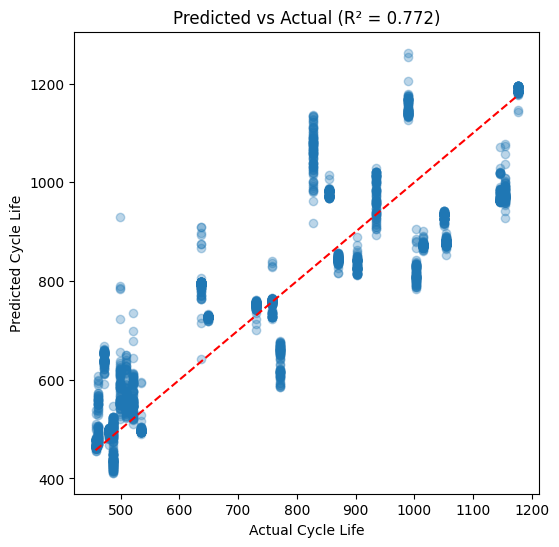

In [ ]:
#visualisation of result
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, xgb_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycle Life")
plt.ylabel("Predicted Cycle Life")
plt.title(f"Predicted vs Actual (R² = {xgb_r2:.3f})")
plt.show()

In [ ]:
import pickle

model_path = "/content/drive/MyDrive/xgboost_battery_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(xgb_model, f)

print(f"Model saved to: {model_path}")

Model saved to: /content/drive/MyDrive/xgboost_battery_model.pkl


In [ ]:
import pickle

model_path = "/content/drive/MyDrive/xgboost_battery_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(xgb_model, f)

print(f"Model saved to: {model_path}")

Model saved to: /content/drive/MyDrive/xgboost_battery_model.pkl
